# 02 A/B Test Primary Outcome Analysis

This notebook evaluates whether the Diabetes Peer Support outreach strategy improved diabetes testing compliance compared with Standard Outreach.

The primary outcome is:

`diabetes_testing_compliant`

The secondary outcome is:

`diabetes_testing_compliance_rate`

Exploratory outcomes include:

- `a1c_test_completed`
- `kidney_screening_completed`
- `eye_exam_completed`

This analysis uses an intent-to-treat framework, meaning members are compared based on randomized assignment rather than later enrollment or attendance behavior.

Because this project uses synthetic data, results should be interpreted as a portfolio demonstration of A/B testing methodology, not as real clinical evidence.

## 1. Imports

In [1]:
import pandas as pd # Used for data loading and tabular analysis
import numpy as np # Used for numerical calculations
import matplotlib.pyplot as plt # Used for basic visualizations
from pathlib import Path # Used for project-relative file paths
from scipy import stats # Used for hypothesis testing



## 2. Load Dataset

In [2]:
# Define project root
project_root = Path("..")

# Define data path
data_path = project_root / "data" / "raw" / "mock_diabetes_peer_support_ab_test.csv"

# Load dataset

df = pd.read_csv(data_path)

# Preview first five rows

df.head()

,member_id,age,gender,region,plan_type,target_population_flag,diabetes_severity_score,chronic_condition_count,baseline_engagement_score,health_literacy_score,...,peer_leader_supervised,contact_frequency_per_month,assigned_diabetes_tests_count,a1c_test_completed,kidney_screening_completed,eye_exam_completed,diabetes_tests_completed_count,diabetes_testing_compliance_rate,diabetes_testing_compliant,program_data_quality_issue
0,1,64,Male,Urban,Medicaid,1,0.263,1,0.866,0.349,...,0,1,3,1,1,1,3,1.000,1,0
1,2,69,Male,Rural,D-SNP,1,0.361,5,0.253,0.533,...,1,2,3,1,0,0,1,0.333,0,0
2,3,74,Female,Urban,Medicare Advantage,1,0.598,2,0.483,0.189,...,0,1,3,1,0,0,1,0.333,0,0
3,4,72,Male,Urban,Medicare Advantage,1,0.189,4,0.377,0.811,...,1,2,3,0,1,1,2,0.667,0,0
4,5,42,Female,Suburban,Medicaid,1,0.759,3,0.541,0.606,...,0,1,3,1,1,0,2,0.667,0,0


## 3. Confirm Experiment Groups

In [3]:
experiment_group_summary = pd.DataFrame({
    "count": df["experiment_group"].value_counts(),
    "proportion": df["experiment_group"].value_counts(normalize=True).round(3)
})

experiment_group_summary

,count,proportion
experiment_group,,
Diabetes Peer Support,2078,0.52
Standard Outreach,1922,0.48


## 4. Define Analysis Groups

In [4]:
# Create control group dataframe
control = df[df["experiment_group"] == "Standard Outreach"]

# Create treatment group dataframe
treatment = df[df["experiment_group"] == "Diabetes Peer Support"]

The control group received Standard Outreach.

The treatment group was assigned to Diabetes Peer Support

This comparison follows an intent-to-treat structure because members are compared based on randomized assignment, not only based on whether they enrolled or attended sessions. 

# Section A: Primary Outcome -- Binary Compliance

## 5. Compare Binary Compliance Rate

In [5]:
# Compare binary compliance rate by group
binary_summary = (
    df.groupby("experiment_group")["diabetes_testing_compliant"].agg(["count","mean"]).round(3)
)

binary_summary

,count,mean
experiment_group,,
Diabetes Peer Support,2078,0.423
Standard Outreach,1922,0.376


The binary compliance outcome equals 1 when a member completed enough assigned diabetes tests to be classified as compliant.

Because each member has 3 assigned diabetes tests, this binary outcome is interpreted as the member-level compliance conversion outcome for the A/B test.

In this synthetic dataset, the 0.75 compliance threshold effectively requires completing all 3 assigned diabetes tests because 2 out of 3 equals 0.667.

## 6. Calculate Binary Outcome Lift

In [6]:
# Calculate binary compliance rates
control_binary_rate = control["diabetes_testing_compliant"].mean()
treatment_binary_rate = treatment["diabetes_testing_compliant"].mean()

# Calculate absolute and relative lift
binary_absolute_lift = treatment_binary_rate - control_binary_rate
binary_relative_lift = binary_absolute_lift / control_binary_rate

binary_lift_summary = pd.DataFrame({
    "Metric": [
        "Control Binary Compliance Rate",
        "Treatment Binary Compliance Rate",
        "Absolute Lift",
        "Relative Lift"
    ],
    "Value": [
        control_binary_rate,
        treatment_binary_rate,
        binary_absolute_lift,
        binary_relative_lift
    ]
})

binary_lift_summary["Value"] = binary_lift_summary["Value"].round(3)

binary_lift_summary

,Metric,Value
0,Control Binary Compliance Rate,0.376
1,Treatment Binary Compliance Rate,0.423
2,Absolute Lift,0.047
3,Relative Lift,0.126


## 7. Two-Proportion Z-Test

In [7]:
# Calculate number of compliant members in each group
success_treatment = treatment["diabetes_testing_compliant"].sum()
success_control = control["diabetes_testing_compliant"].sum()

# Calculate group sizes
n_treatment = len(treatment)
n_control = len(control)

# Calculate pooled compliance rate
pooled_rate = (success_treatment + success_control) / (n_treatment + n_control) 

# Calculate standard error for two-proportion z-test
se_pooled = np.sqrt(
    pooled_rate * (1 - pooled_rate) * (1 / n_treatment + 1 / n_control)
)

# Calculate z-statistic
z_stat = (treatment_binary_rate - control_binary_rate) / se_pooled

# Calculate two-sided p-value
p_value_z = 2 * (1 - stats.norm.cdf(abs(z_stat)))

z_test_result = pd.DataFrame({
    "Test": ["Two-proportion z-test"],
    "z_statistic": [z_stat],
    "p_value": [p_value_z]
})

z_test_result.round(4)

,Test,z_statistic,p_value
0,Two-proportion z-test,3.0539,0.0023


## 8. Confidence Interval for Binary Absolute Lift

In [8]:
# Calculate unpooled standard error for confidence interval

se_binary_diff = np.sqrt(
    treatment_binary_rate * (1 - treatment_binary_rate) / n_treatment
    + control_binary_rate * (1 - control_binary_rate) / n_control
)

z_critical = stats.norm.ppf(0.975) # Yields 1.95996

# Calculate 95% confidence interval 
binary_ci_lower = binary_absolute_lift - z_critical * se_binary_diff
binary_ci_upper = binary_absolute_lift + z_critical * se_binary_diff

binary_ci_summary = pd.DataFrame({
    "Metric": ["Binary Absolute Lift", "95% CI Lower", "95% CI Upper"],
    "Value": [binary_absolute_lift, binary_ci_lower, binary_ci_upper]
})

binary_ci_summary["Value"] = binary_ci_summary["Value"].round(3)

binary_ci_summary



,Metric,Value
0,Binary Absolute Lift,0.047
1,95% CI Lower,0.017
2,95% CI Upper,0.078


# Section B: Secondary Outcome -- Compliance Rate

## 9. Compare Average Compliance Rate

In [9]:
# Compare average diabetes testing compliance rate by group
primary_summary = (
    df.groupby("experiment_group")["diabetes_testing_compliance_rate"].agg(["count", "mean", "std"]).round(3)
)

primary_summary

,count,mean,std
experiment_group,,,
Diabetes Peer Support,2078,0.745,0.260
Standard Outreach,1922,0.713,0.269


## 10. Calculate Absolute and Relative Lift

In [10]:
# Calculate control mean compliance rate
control_rate = control["diabetes_testing_compliance_rate"].mean()

# Calculate treatment mean compliance rate
treatment_rate = treatment["diabetes_testing_compliance_rate"].mean()

# Calculate absolute lift
absolute_lift = treatment_rate - control_rate

# Calculate relative lift
relative_lift = absolute_lift / control_rate

# Create summary table
lift_summary = pd.DataFrame({
    "Metric": [
        "Control Mean Compliance Rate",
        "Treatment Mean Compliance Rate",
        "Absolute Lift",
        "Relative Lift"
    ],
    "Value": [
        control_rate,
        treatment_rate,
        absolute_lift,
        relative_lift
    ]
})

lift_summary["Value"] = lift_summary["Value"].round(3)

lift_summary

,Metric,Value
0,Control Mean Compliance Rate,0.713
1,Treatment Mean Compliance Rate,0.745
2,Absolute Lift,0.032
3,Relative Lift,0.045


## 11. Visualize Average Compliance Rate

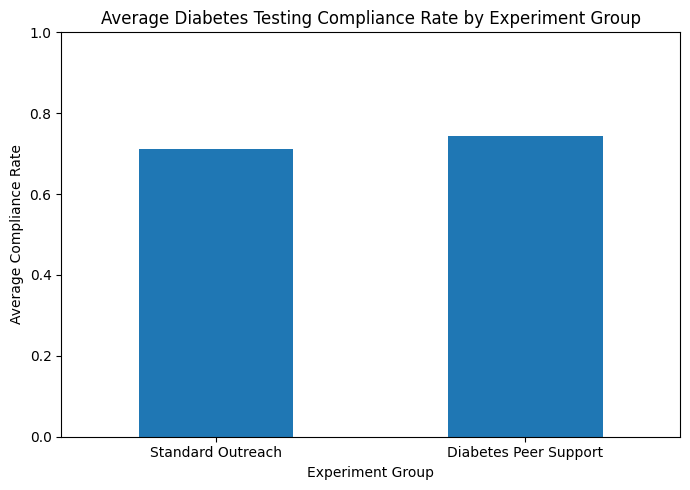

In [11]:
# Calculate mean compliance rate by experiment group
compliance_by_group = (
    df.groupby("experiment_group")["diabetes_testing_compliance_rate"]
    .mean()
    .sort_values()
)

# Create bar chart
compliance_by_group.plot(kind="bar", figsize=(7, 5))

plt.title("Average Diabetes Testing Compliance Rate by Experiment Group")
plt.ylabel("Average Compliance Rate")
plt.xlabel("Experiment Group")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 12. Welch T-test for Average Compliance Rate

In [12]:
# Run Welch's t-test for difference in mean compliance rate
t_stat, p_value = stats.ttest_ind(
    treatment["diabetes_testing_compliance_rate"],
    control["diabetes_testing_compliance_rate"],
    equal_var=False
)

t_test_result = pd.DataFrame({
    "Test": ["Welch two-sample t-test"],
    "t_statistic": [t_stat],
    "p_value": [p_value]
})

t_test_result.round(4)

,Test,t_statistic,p_value
0,Welch two-sample t-test,3.8217,0.0001


Null hypothesis: Diabetes Peer Support and Standard Outreach have the same average diabetes testing compliance rate.

Alternative hypothesis: Diabetes Peer Support and Standard Outreach have different average diabetes testing compliance rates.

Because this is synthetic randomized data, the p-value is used as a practice tool for A/B testing interpretation, not as real clinical evidence.

## 13. Confidence Interval for Absolute Lift

In [13]:
# Calculate sample sizes
n_treatment = treatment["diabetes_testing_compliance_rate"].count()
n_control = control["diabetes_testing_compliance_rate"].count()

# Calculate sample standard deviations
std_treatment = treatment["diabetes_testing_compliance_rate"].std()
std_control = control["diabetes_testing_compliance_rate"].std()

# Calculate standard error of difference in means
se_diff = np.sqrt(
    (std_treatment ** 2 / n_treatment)
    + (std_control ** 2 / n_control)
)

z_critical = stats.norm.ppf(0.975) # Yields 1.95996

# Calculate 95% confidence interval
ci_lower = absolute_lift - z_critical * se_diff
ci_upper = absolute_lift + z_critical * se_diff

ci_summary = pd.DataFrame({
    "Metric": ["Absolute Lift", "95% CI Lower", "95% CI Upper"],
    "Value": [absolute_lift, ci_lower, ci_upper]
})

ci_summary["Value"] = ci_summary["Value"].round(3)

ci_summary

,Metric,Value
0,Absolute Lift,0.032
1,95% CI Lower,0.016
2,95% CI Upper,0.048


The confidence interval gives a plausible range for the difference in average compliance rate between the two randomized groups.

If the interval is entirely above 0, the observed treatment group advantage is unlikely to be explained by random variation alone under this synthetic experiment.

# Section C: Diabetes Test Component Analysis

## 14. Compare Individual Test Completion

In [14]:
# Compare individual diabetes test completion rates by group
test_component_summary = (
    df.groupby("experiment_group")[
        [
            "a1c_test_completed",
            "kidney_screening_completed",
            "eye_exam_completed"
        ]
    ].mean().round(3)
)

test_component_summary

,a1c_test_completed,kidney_screening_completed,eye_exam_completed
experiment_group,,,
Diabetes Peer Support,0.832,0.742,0.66
Standard Outreach,0.809,0.718,0.61


This table shows whether the peer-support program improved all testing components equally or whether some measures remained harder to close.

## 15. Visualize Individual Test Completion

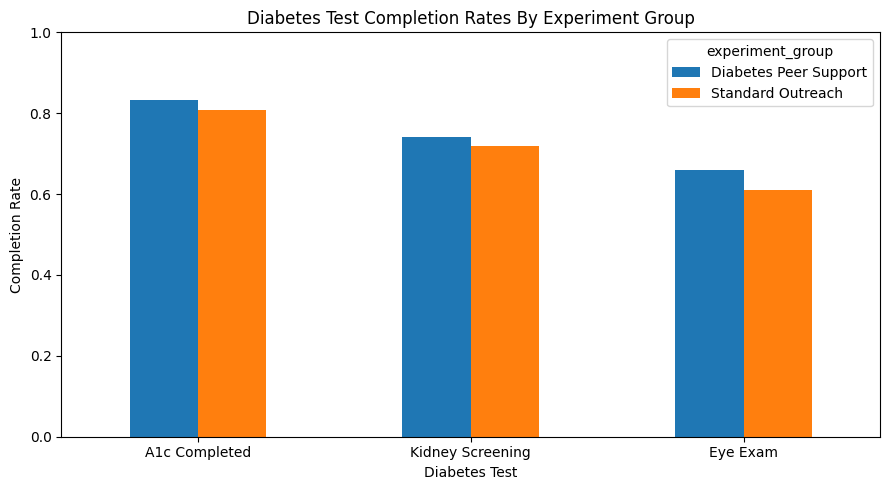

In [15]:
# Transpose for easier grouped bar chart

df_plot = test_component_summary.T
df_plot.index = ['A1c Completed', 'Kidney Screening', 'Eye Exam']
df_plot.plot(kind="bar", figsize = (9,5))

plt.title("Diabetes Test Completion Rates By Experiment Group")
plt.ylabel("Completion Rate")
plt.xlabel("Diabetes Test")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Section D: Intent-to-Treat Interpretation

## 16. Intent-to-Treat Interpretation

The primary comparison uses randomized assignment:

- Standard Outreach
- Diabetes Peer Support

This is an intent-to-treat comparison. Members assigned to Diabetes Peer Support are included in the treatment group even if they did not enroll or attend a session.

This matters because comparing only attendees against Standard Outreach would introduce selection bias. Members who attend peer-support sessions may differ from non-attendees in motivation, transportation access, health literacy, or baseline engagement.

Therefore, the main A/B test result estimates the average effect of being assigned to the peer-support outreach strategy, not the isolated effect of attending sessions.

## 17. Findings

This notebook estimated the primary A/B testing result for the Diabetes Peer Support outreach experiment using an intent-to-treat framework.

The primary binary compliance outcome shows that members assigned to Diabetes Peer Support had a higher compliance rate than members assigned to Standard Outreach.

Key findings:

- Standard Outreach binary compliance rate: 37.6%
- Diabetes Peer Support binary compliance rate: 42.3%
- Absolute lift: 4.7 percentage points
- Relative lift: 12.6%
- Two-proportion z-test p-value: 0.0023
- 95% confidence interval for absolute lift: 1.7 to 7.8 percentage points

The average diabetes testing compliance rate also improved:

- Standard Outreach average compliance rate: 71.3%
- Diabetes Peer Support average compliance rate: 74.5%
- Absolute lift: 3.2 percentage points
- 95% confidence interval: 1.6 to 4.8 percentage points

Because members were analyzed based on randomized assignment, this is an intent-to-treat comparison. The result estimates the effect of being assigned to the Diabetes Peer Support outreach strategy, not the isolated effect of attending peer-support sessions.

The individual test completion analysis suggests that improvement was not identical across all diabetes testing components. This should be treated as exploratory because testing multiple outcomes increases the risk of overinterpreting secondary findings.

Important limitation:

This project uses synthetic data. The results demonstrate A/B testing methodology and healthcare outreach interpretation, not real-world clinical evidence.